# Venezuela 2026 — seismic-only vs joint-InSAR model, and an InSAR primer

Two goals:
1. **Compare the models and moment-rate functions** from the **seismic-only** inversion (ffm.5,
   teleseismic body + surface waves) and the **joint** inversion that adds **InSAR** (ffm.6).
2. **Explain, from scratch, what InSAR is, what we are fitting, and how to judge the fit** — no prior
   InSAR background assumed.

---
## Part 0 — InSAR in plain terms

**What is InSAR?** *Interferometric Synthetic Aperture Radar.* A radar satellite (here **Sentinel-1**)
flies over the same ground on two dates — **before and after** the earthquake — and each time measures
the *phase* of the radar echo from the ground. Differencing the two phases gives how much the
ground–satellite **distance** changed between the passes. That distance change is the coseismic
**ground displacement**, measured continuously over a whole region (an image), not just at stations.

**What exactly is measured — "line of sight" (LOS).** The satellite looks down at a slant (here
**~42° from vertical**). It cannot measure full 3-D motion; it measures only the **projection of the
ground displacement onto the radar look direction** (ground→satellite). So at each pixel the
observable is a single number:

$$\mathrm{LOS} = d_E\,\hat{l}_E + d_N\,\hat{l}_N + d_U\,\hat{l}_U$$

where $(d_E,d_N,d_U)$ is the 3-D ground displacement and $(\hat{l}_E,\hat{l}_N,\hat{l}_U)$ is the
unit **look vector**. By convention here, positive LOS = ground moved **away** from the satellite,
negative = **toward** it. (Sentinel-1 is C-band, wavelength 5.6 cm; one interferometric "fringe" =
half a wavelength = **2.8 cm** of LOS.)

**Two look directions.** We use two tracks that view from **opposite sides** — one looking from the
**east**, one from the **west** (both ~42° incidence). Because each is sensitive to a different mix of
E/N/U motion, together they constrain the (mostly horizontal, strike-slip) surface displacement much
better than one alone.

**What do we fit?** The finite-fault model predicts the full 3-D surface displacement produced by the
slip (via elastic Green's functions for the layered Earth). We **project that prediction onto each
pixel's look vector** to get a predicted LOS, and adjust the slip so predicted LOS matches observed
LOS at every pixel — **jointly** with the seismic waveforms. A smooth **orbital ramp** (a planar
trend, from small orbit/atmosphere errors) is solved simultaneously as a nuisance term and removed.

**How do we judge the fit?** Two ways, both shown below:
- **Visually:** maps of *observed*, *modeled*, and *residual (obs − model)* LOS. A good fit reproduces
  the observed lobes; the residual map should be small and pattern-less.
- **Numerically — variance reduction (VR):** $\mathrm{VR}=1-\frac{\sum(\mathrm{obs}-\mathrm{model})^2}{\sum \mathrm{obs}^2}$.
  VR = 1 is a perfect fit; VR = 0 is no better than predicting zero everywhere.

In [1]:
import os, sys, json
import numpy as np, re
import matplotlib.pyplot as plt
from IPython.display import Image, display
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(ROOT, 'scripts'))
import fig_insar, usgs_compare as uc
get_ipython().run_line_magic('matplotlib', 'inline')  # imported fig modules set Agg; restore inline rendering
SEIS  = os.path.join(ROOT, 'results', 'ffm.5/NP1.big')  # seismic only
JOINT = os.path.join(ROOT, 'results', 'ffm.6/NP1.big')  # + InSAR
USGS  = os.path.join(ROOT, 'data', 'usgs')

# viewing geometry of the two Sentinel-1 scenes
a=np.array([[float(x) for x in l.split()] for l in open(os.path.join(JOINT,'imagery_data.txt')).read().splitlines()[1:] if len(l.split())>=8])
obs,lud,lns,lew=a[:,4],a[:,5],a[:,6],a[:,7]
import pandas as pd
rows=[]
for nm,sl in [('scene 1 (p106)',slice(0,110)),('scene 2 (p25)',slice(110,None))]:
    rows.append(dict(scene=nm, points=len(obs[sl]),
                     incidence_deg=round(np.degrees(np.arccos(np.abs(lud[sl]).mean())),0),
                     look_azimuth_deg=round(np.degrees(np.arctan2(lew[sl].mean(),lns[sl].mean()))%360,0),
                     LOS_min_cm=round(obs[sl].min(),0), LOS_max_cm=round(obs[sl].max(),0),
                     mean_abs_LOS_cm=round(np.abs(obs[sl]).mean(),1)))
display(pd.DataFrame(rows))
print('look-azimuth ~79 deg = looking from the EAST; ~281 deg = looking from the WEST (complementary)')

,scene,points,incidence_deg,look_azimuth_deg,LOS_min_cm,LOS_max_cm,mean_abs_LOS_cm
0,scene 1 (p106),110,42.0,79.0,-17.0,26.0,5.8
1,scene 2 (p25),2519,42.0,281.0,0.0,41.0,25.6


look-azimuth ~79 deg = looking from the EAST; ~281 deg = looking from the WEST (complementary)


---
## Part 1 — How well is the InSAR fit? (the joint model, ffm.6)

Below, for each Sentinel-1 scene: **observed** LOS, **modeled** LOS (fault slip + orbital ramp), and
the **residual** (obs − model), all on the same colour scale. Red = away from satellite, blue = toward.

InSAR fit: overall VR=0.967, 2629 points, 2 tracks -> results/ffm.6/NP1.big/plots/InSAR_fit.png


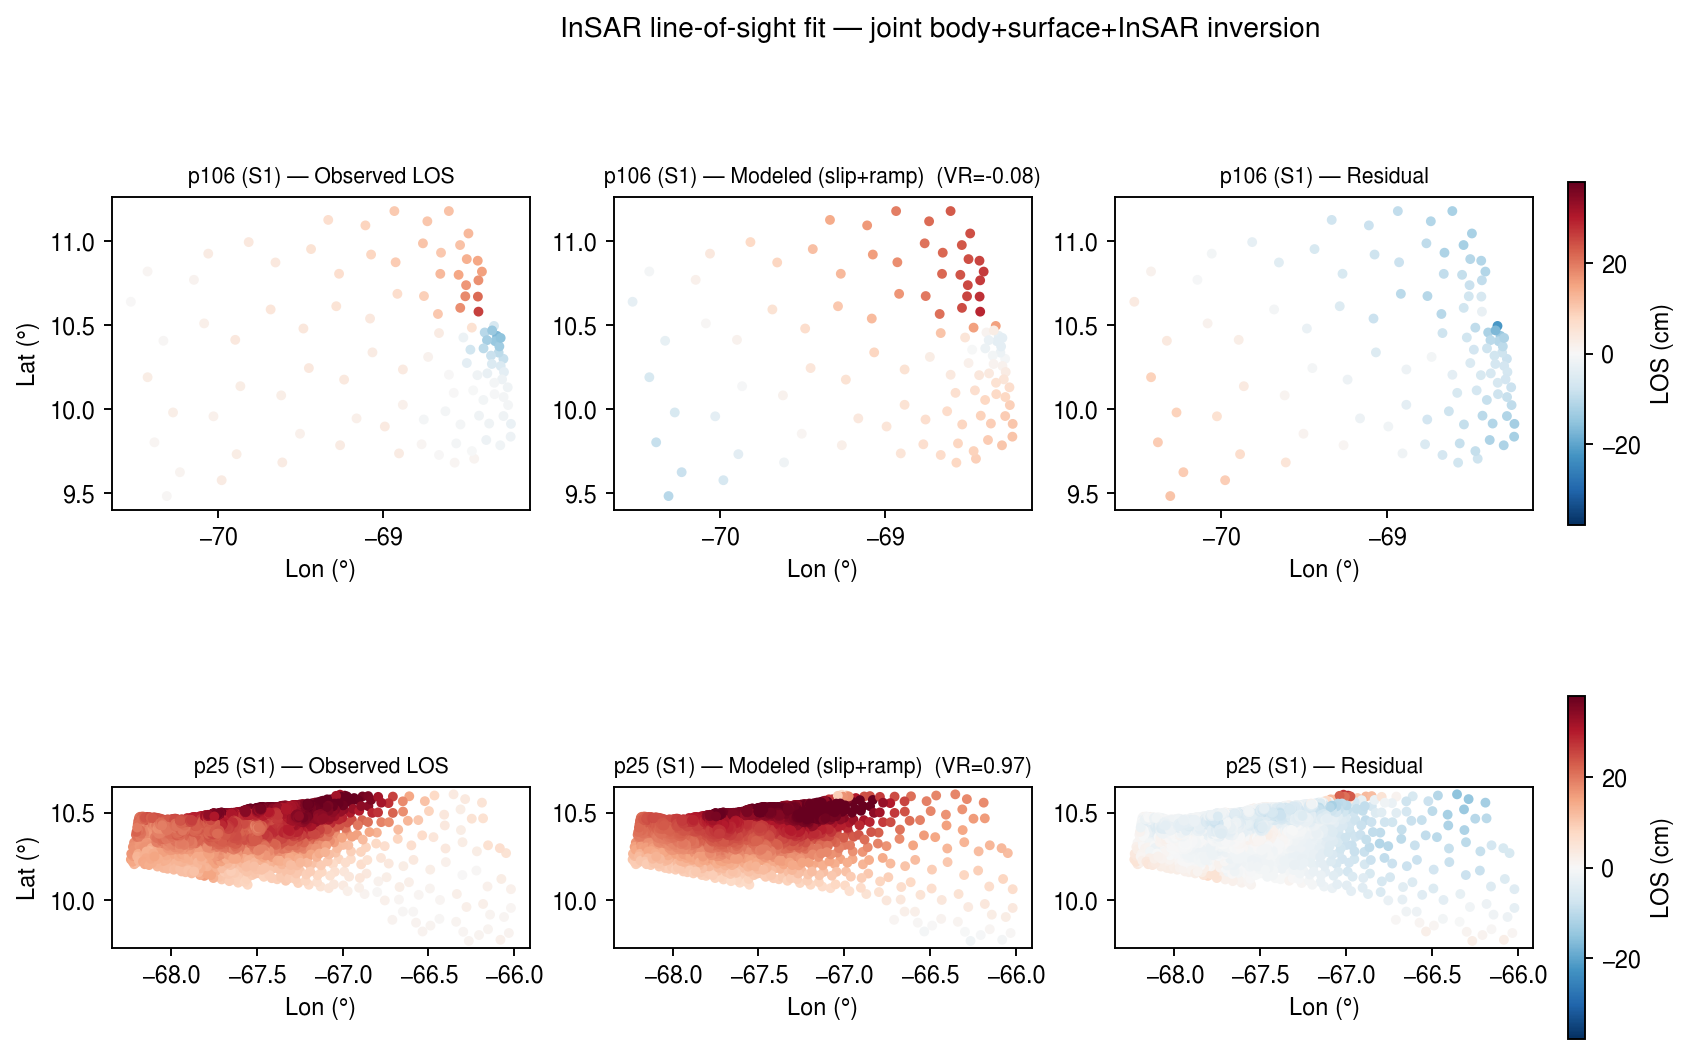

In [2]:
display(Image(fig_insar.plot(JOINT)))

**How to read it.** In the *observed* and *modeled* panels the coloured lobes are the ground
deformation caused by the rupture; a good model makes the middle panel look like the left panel. In
the *residual* panel, near-white/pale means "well fit". The large western scene (p25, 2519 pixels,
signal up to ~40 cm) is reproduced in both shape and amplitude; the small eastern scene (p106, 110
pixels) matches in pattern but its absolute offset is less well determined (few pixels, dominated by
the ramp).

The two quantitative fit checks:

overall variance reduction: 0.967  (RMS residual 4.8 cm)
  scene 1 (p106) VR=-0.083  RMS resid=8.3 cm
  scene 2 (p25)  VR=0.971  RMS resid=4.6 cm


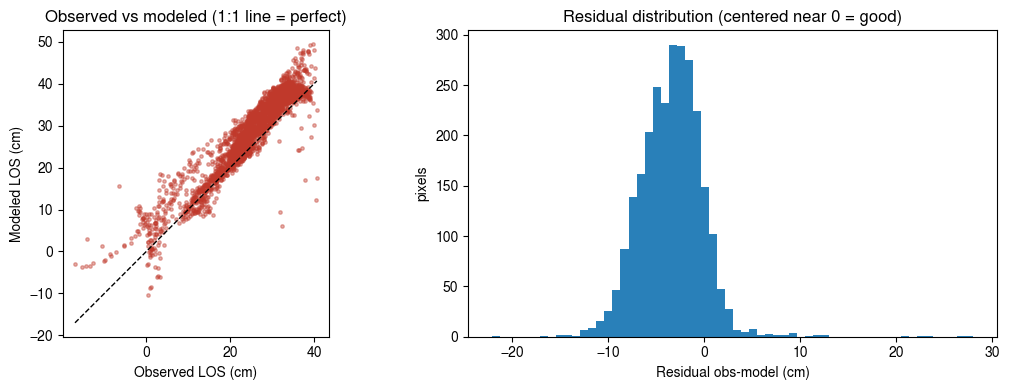

In [3]:
def cols(path,c): return np.array([float(l.split()[c]) for l in open(path).read().splitlines()[1:] if len(l.split())>=c+1])
obs=cols(os.path.join(JOINT,'imagery_data.txt'),4)
syn=cols(os.path.join(JOINT,'imagery_synthetics.txt'),4)
ramp=cols(os.path.join(JOINT,'imagery_ramp.txt'),4)
model=syn+ramp; res=obs-model
sizes=[int(l.split()[0]) for l in open(os.path.join(JOINT,'imagery_weights.txt')).read().splitlines()[1:] if l.split()]
b=np.cumsum([0]+sizes)
def vr(o,m): return 1-np.sum((o-m)**2)/np.sum(o**2)
print('overall variance reduction: %.3f  (RMS residual %.1f cm)'%(vr(obs,model),np.sqrt(np.mean(res**2))))
for nm,i in [('scene 1 (p106)',0),('scene 2 (p25)',1)]:
    sl=slice(b[i],b[i+1]); print('  %-14s VR=%.3f  RMS resid=%.1f cm'%(nm,vr(obs[sl],model[sl]),np.sqrt(np.mean(res[sl]**2))))

fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].scatter(obs,model,s=6,alpha=.4,c='#c0392b'); lim=[obs.min(),obs.max()]
ax[0].plot(lim,lim,'k--',lw=1); ax[0].set_xlabel('Observed LOS (cm)'); ax[0].set_ylabel('Modeled LOS (cm)')
ax[0].set_title('Observed vs modeled (1:1 line = perfect)'); ax[0].set_aspect('equal')
ax[1].hist(res,bins=60,color='#2980b9'); ax[1].set_xlabel('Residual obs-model (cm)'); ax[1].set_ylabel('pixels')
ax[1].set_title('Residual distribution (centered near 0 = good)')
plt.tight_layout(); plt.show()

The 1:1 scatter hugging the diagonal and the residuals clustered near zero are what "well fit"
means: the modeled LOS matches the observed LOS pixel-by-pixel, with a variance reduction of ~0.97
for the large scene — i.e. the model explains ~97% of the observed deformation signal.

---
## Part 2 — Seismic-only (ffm.5) vs joint-with-InSAR (ffm.6)

Now the model comparison. Both use the **same** teleseismic data and fault geometry; ffm.6 adds the
InSAR. The seismic fit is essentially unchanged (misfit 0.106 both), so any differences below are the
InSAR pulling on the model.

### 2a. Moment-rate functions

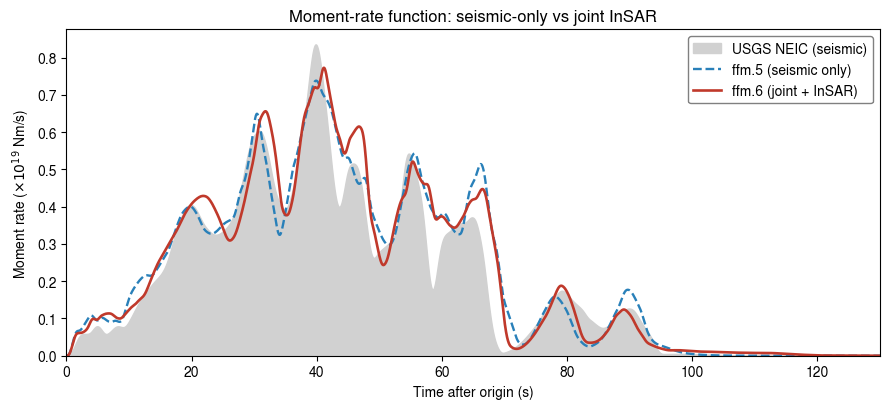

M0: seismic-only 2.83e+20 | joint 2.84e+20 Nm  -> Mw 7.57 vs 7.57


In [4]:
t5,m5=uc.parse_mr(os.path.join(SEIS,'STF.txt'))
t6,m6=uc.parse_mr(os.path.join(JOINT,'STF.txt'))
tu,mu=uc.parse_mr(os.path.join(USGS,'moment_rate.mr'))
fig,ax=plt.subplots(figsize=(9,4.2))
ax.fill_between(tu,mu/1e19,color='0.82',label='USGS NEIC (seismic)')
ax.plot(t5,m5/1e19,color='#2980b9',lw=1.7,ls='--',label='ffm.5 (seismic only)')
ax.plot(t6,m6/1e19,color='#c0392b',lw=1.9,label='ffm.6 (joint + InSAR)')
ax.set_xlim(0,130); ax.set_ylim(bottom=0); ax.set_xlabel('Time after origin (s)')
ax.set_ylabel(r'Moment rate ($\times10^{19}$ Nm/s)'); ax.set_title('Moment-rate function: seismic-only vs joint InSAR')
ax.legend(framealpha=1,edgecolor='0.5'); plt.tight_layout(); plt.show()
def Mo(t,m): return np.trapz(m,t)
print('M0: seismic-only %.2e | joint %.2e Nm  -> Mw %.2f vs %.2f'%(Mo(t5,m5),Mo(t6,m6),
      (2/3)*(np.log10(Mo(t5,m5))-9.1),(2/3)*(np.log10(Mo(t6,m6))-9.1)))

The **moment-rate functions are almost identical** — same total moment (Mw 7.57), same ~40 s
dominant pulse and multi-pulse shape. This is expected and reassuring: the *time history and total
size* of the rupture are set by the seismic waves, which InSAR (a **static**, before-vs-after snapshot
with no time information) does not change. **InSAR reshapes *where* the slip is, not *when*.**

### 2b. Slip distribution — maps and difference

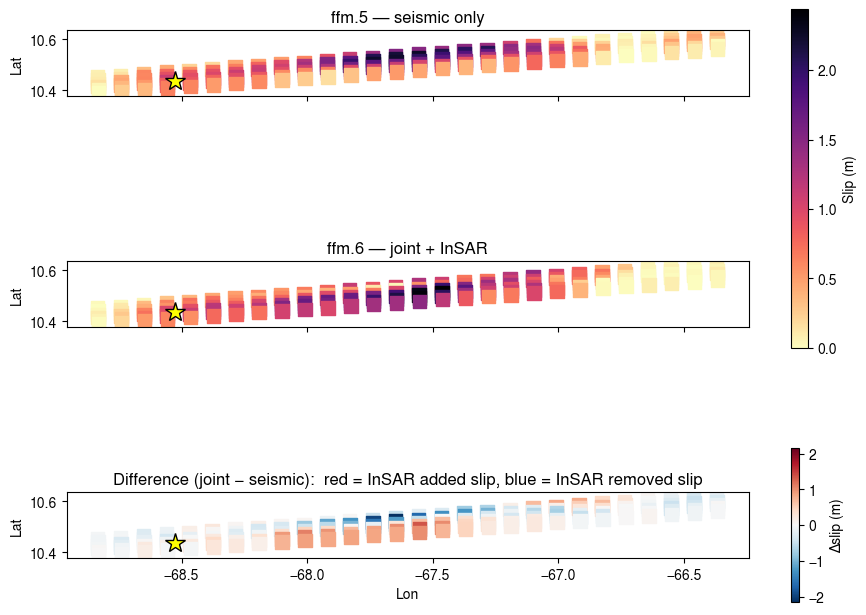

slip-pattern correlation (ffm.5 vs ffm.6): 0.55  (all seismic-only tweaks were >0.9)


In [5]:
def load(run):
    txt=open(os.path.join(run,'Solution.txt')).read().splitlines()
    i0=next(i for i,l in enumerate(txt) if 'slip' in l and 'rake' in l)+1
    a=np.array([[float(x) for x in l.split()[:11]] for l in txt[i0:] if len(l.split())>=11])
    return dict(lat=a[:,0],lon=a[:,1],dep=a[:,2],slip=a[:,3]/100)
d5,d6=load(SEIS),load(JOINT); vmax=max(d5['slip'].max(),d6['slip'].max())
fig,ax=plt.subplots(3,1,figsize=(11,8.5),sharex=True,sharey=True)
asp=1/np.cos(np.radians(10.436))
for a_,d,t in [(ax[0],d5,'ffm.5 — seismic only'),(ax[1],d6,'ffm.6 — joint + InSAR')]:
    sc=a_.scatter(d['lon'],d['lat'],c=d['slip'],cmap='magma_r',vmin=0,vmax=vmax,s=95,marker='s')
    a_.plot(-68.5277,10.436,marker='*',ms=15,mfc='yellow',mec='k'); a_.set_title(t); a_.set_ylabel('Lat'); a_.set_aspect(asp)
fig.colorbar(sc,ax=[ax[0],ax[1]],shrink=.8,label='Slip (m)')
dd=d6['slip']-d5['slip']; L=np.abs(dd).max()
sc2=ax[2].scatter(d6['lon'],d6['lat'],c=dd,cmap='RdBu_r',vmin=-L,vmax=L,s=95,marker='s')
ax[2].plot(-68.5277,10.436,marker='*',ms=15,mfc='yellow',mec='k'); ax[2].set_aspect(asp)
ax[2].set_title('Difference (joint − seismic):  red = InSAR added slip, blue = InSAR removed slip')
ax[2].set_xlabel('Lon'); ax[2].set_ylabel('Lat'); fig.colorbar(sc2,ax=ax[2],shrink=.8,label='Δslip (m)')
plt.show()
print('slip-pattern correlation (ffm.5 vs ffm.6): %.2f  (all seismic-only tweaks were >0.9)'%np.corrcoef(d5['slip'],d6['slip'])[0,1])

Adding InSAR changes the slip more than any purely-seismic adjustment did (pattern correlation
drops to ~0.55). The difference panel shows InSAR redistributing slip within the coastal zone it
images.

### 2c. Where the slip moved — depth and along-strike

slip-weighted centroid depth:  seismic 16.8 km  ->  joint 19.0 km  (InSAR pulls slip deeper)

depth band     seismic   joint    change
   0- 8 km       0.59     0.59    -0.00 m
   8-16 km       1.02     0.60    -0.42 m
  16-30 km       0.67     0.87    +0.20 m


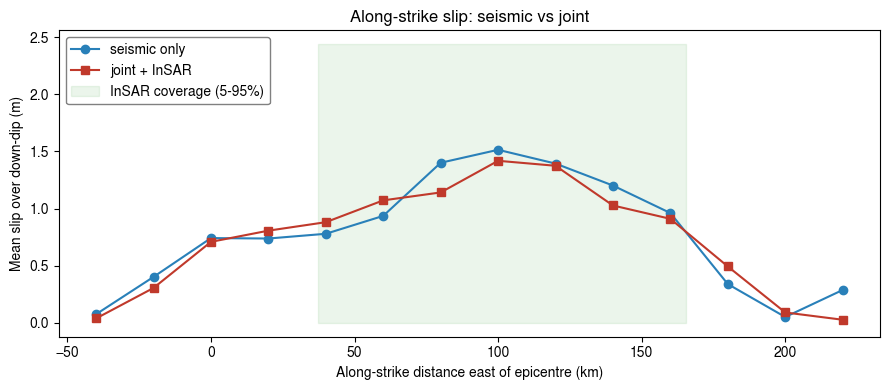

In [6]:
cd=lambda d: np.average(d['dep'],weights=d['slip'])
print('slip-weighted centroid depth:  seismic %.1f km  ->  joint %.1f km  (InSAR pulls slip deeper)'%(cd(d5),cd(d6)))
print('\ndepth band     seismic   joint    change')
for lo,hi in [(0,8),(8,16),(16,30)]:
    m5=(d5['dep']>=lo)&(d5['dep']<hi); m6=(d6['dep']>=lo)&(d6['dep']<hi)
    print('  %2d-%2d km       %.2f     %.2f    %+.2f m'%(lo,hi,d5['slip'][m5].mean(),d6['slip'][m6].mean(),d6['slip'][m6].mean()-d5['slip'][m5].mean()))
# along-strike
ew=lambda d:(d['lon']+68.5277)*111.32*np.cos(np.radians(d['lat']))
bins=np.arange(-50,240,20); ctr=.5*(bins[:-1]+bins[1:])
prof=lambda d:[d['slip'][(ew(d)>=bins[i])&(ew(d)<bins[i+1])].mean() if ((ew(d)>=bins[i])&(ew(d)<bins[i+1])).any() else 0 for i in range(len(ctr))]
il=cols(os.path.join(JOINT,'imagery_data.txt'),3); # lon of InSAR pts
ix=(il+68.5277)*111.32*np.cos(np.radians(10.436))
fig,ax=plt.subplots(figsize=(9,4))
ax.plot(ctr,prof(d5),'o-',color='#2980b9',label='seismic only'); ax.plot(ctr,prof(d6),'s-',color='#c0392b',label='joint + InSAR')
ax.fill_between([np.percentile(ix,5),np.percentile(ix,95)],0,vmax,color='green',alpha=.08,label='InSAR coverage (5-95%)')
ax.set_xlabel('Along-strike distance east of epicentre (km)'); ax.set_ylabel('Mean slip over down-dip (m)')
ax.set_title('Along-strike slip: seismic vs joint'); ax.legend(framealpha=1,edgecolor='0.5'); plt.tight_layout(); plt.show()

**Depth:** InSAR pulls the slip centroid **deeper (~16.8 → 19.0 km)** — it drains the mid-crust
(8–16 km) and adds slip below (16–30 km). Physically, the *width and amplitude* of the observed
surface deformation is better matched by slightly deeper slip than the teleseismic data alone had
placed. **Along-strike:** within the InSAR-covered coastal zone (green band, ~40–120 km east, where
~83% of the pixels are) the main slip patch is **smoothed and shifted slightly west**; the far-east
offshore tip (no InSAR pixels) is unchanged and remains seismically controlled.

---
## Take-homes

- **InSAR measures static ground displacement projected onto the radar line of sight** (here ~42°
  incidence, two complementary look directions). We fit that LOS at 2629 pixels with the model's
  predicted surface displacement plus an orbital ramp.
- **The InSAR is well fit** — variance reduction **~0.97** for the large scene; observed and modeled
  LOS agree pixel-by-pixel (1:1 scatter on the diagonal, residuals centered at zero).
- **Moment-rate functions are essentially identical** (Mw 7.57, ~40 s peak): InSAR is static, so it
  does not change *when* or *how big* — only *where*.
- **Slip distribution changes meaningfully** (pattern correlation 0.55): InSAR pulls the coastal slip
  **~2 km deeper** and smooths/shifts the main patch west, over the zone it images; the offshore east
  stays seismically constrained.
- **The seismic fit is preserved** (misfit 0.106), so the two datasets are mutually consistent — the
  joint model is the better-resolved coseismic baseline.